**Ejercicio 1.-** Consideremos la región encerrada por las gráficas de las funciones:

$$
\begin{aligned}
f(x)&=2\tan(1-x^3)\cos(1-x^2)\quad &\text{ en el intervalo }[0, 0.5],\\
g(x)&=f(1-x)\quad&\text{ en el intervalo }[0.5, 0.8],
\end{aligned}
$$
y la poligonal que une los puntos $(0, f(0))$, $(0, 0.5 f(0))$, $(0.5, 0)$, $(0.8, 0.6 f(0))$ y $(0.8, g(0.8))$.

(a) Representar la región y encuadrarla, adecuadamente, para aproximar, por el método de Montecarlo, su área.

(b) Desarrollar el cálculo con  $M = 10^4$ lanzamientos aleatorios sobre la región rectangular.

(c) Hacer un gráfico que ilustre el método.

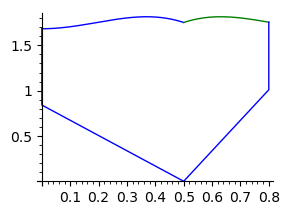

In [1]:
# a) Empezamos dibujando la región

f(x)=2*tan(1-x^3)*cos(1-x^2)
g(x)=f(1-x)
vertices=[(0,f(0)),(0,.5*f(0)),(.5,0),(.8,.6*f(0)),(.8,g(.8))]
region=plot(f,x,0,.5,figsize=3)+plot(g,x,.5,.8,color='green')+line(vertices)
region.show()

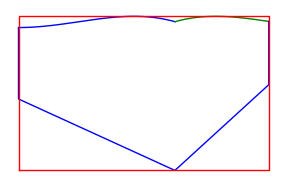

In [2]:
# Ahora intentamos encuadrarla

yM,xM=find_local_maximum(f,0,.5)
a,b,c,d=0,.8,0,yM
encuadre=[(a,c),(b,c),(b,d),(a,d),(a,c)]
diana=region+line(encuadre,color='red')
diana.show(axes=False)

In [3]:
# Obtenemos las ecuaciones de las rectas

m1=(.5*f(0)-0)/(0-.5)
r1(x)=m1*(x-.5)
m2=(.6*f(0)-0)/(.8-.5)
r2(x)=m2*(x-.5)

In [4]:
# b) Calculamos el área por Montecarlo

M=10^4
AreaDiana=(b-a)*(d-c)
fav=0
for _ in xsrange(M):
    xx,yy=uniform(a,b),uniform(c,d)
    if xx<.5:
        fav+=bool((f(xx)-yy)*(r1(xx)-yy)<0)
    else:
        fav+=bool((g(xx)-yy)*(r2(xx)-yy)<0)
AreaDiana.n()*(fav/M)

1.05785873143355

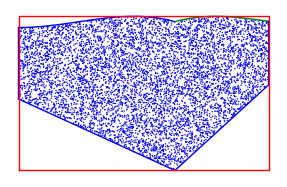

In [5]:
# c) Hacemos un dibujo que ilustra el método

M=10^4
dentro=[]
for _ in xsrange(M):
    xx,yy=uniform(a,b),uniform(c,d)
    if xx<.5:
        if (f(xx)-yy)*(r1(xx)-yy)<0:
            dentro.append((xx,yy))
    else:
        if (g(xx)-yy)*(r2(xx)-yy)<0:
            dentro+=[(xx,yy)]
(diana+points(dentro,pointsize=1)).show(axes=false)

**Ejercicio 2.** Estimar mediante el método de Montecarlo el volumen de
$$
V=\{(x,y,z)\in\mathbb{R}^3: 5(x^4 + y^4 + z^4) - 5(x^2 + y^2 + z^2) +2\le0\}.
$$

*Sugerencia:* Ejecuta la celda siguiente para hacerte una idea de cómo es $V$.  Para representar puntos usa la instrucción de Sagemath $\texttt{point3d}$.

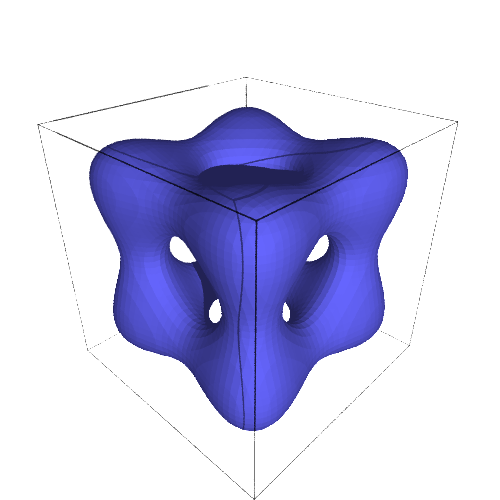

In [6]:
var('x y z')
implicit_plot3d(5*(x^4 + y^4 + z^4) - 5*(x^2 + y^2 + z^2) +2==0, (x,-1.2,1.2), (y,-1.2,1.2), (z,-1.2,1.2)).show(viewer='tachyon')

In [7]:
# Enmarcamos la región en el cubo [-1.2,1.2]^3

M=50000
dentro=[]
for _ in xsrange(M):
    xx=uniform(-1.2,1.2)
    yy=uniform(-1.2,1.2)
    zz=uniform(-1.2,1.2)
    if 5*(xx^4 + yy^4 + zz^4) - 5*(xx^2 + yy^2 + zz^2) +2<=0:
        dentro+=[(xx,yy,zz)]
Volumen=2.4^3*len(dentro)/M
Volumen

4.14415872000000

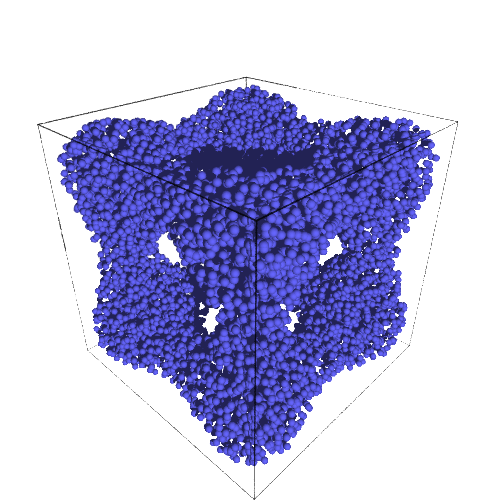

In [8]:
point3d(dentro).show(viewer='tachyon')

--------

**Ejercicio 3.-**  
Vamos con unos amigos a un pub que tiene una diana cuadrada. La diana tiene pintados un triángulo y una circunferencia. Si elegimos un sistema de coordenadas de forma que la diana corresponda al cuadrado $[0, 1]\times[0, 1]$, entonces el triángulo tiene vértices $(0, 1)$, $(1/2, 0)$, $(1, 1/2)$
y la circunferencia tiene centro $(1/2, 1/2)$ y de radio 1/2. Lanzamos dardos de forma aleatoria dentro de la diana. Determinar experimentalmente el número de veces que, en media, será necesario lanzar los dardos antes de conseguir que tres lanzamientos consecutivos caigan dentro de la intersección del triángulo con el círculo encerrado por la circunferencia.

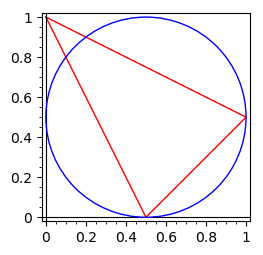

In [9]:
# Empezamos representando la diana

G=circle((1/2,1/2),1/2)
G+=line([(0,1),(1/2,0),(1,1/2),(0,1)],color='red')
show(G,figsize=4,frame=True)

In [10]:
# A continuación definimos una función que simula un lanzamiento y devuelve True si cae
# en la intersección del triángulo con el círculo y False en caso contrario.

def experimento():
    x=random()
    y=random()
    return (x-.5)^2+(y-.5)^2<=.5^2 and y>=(x-(1/2)) and y>=1-2*x and y<=1-x/2


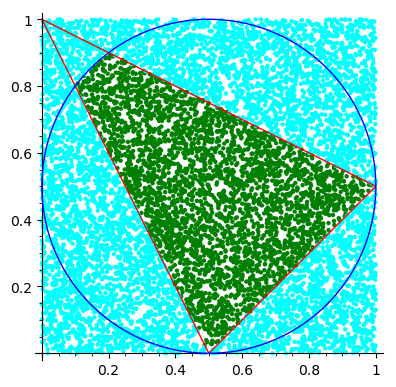

In [11]:
# Comprobemos, experimentalmente, que las condiciones que hemos puesto para que el lanzamiento caiga 
# dentro son las correctas

dentro=[]
fuera=[]
for _ in xsrange(10000):
    x=random()
    y=random()
    if (x-.5)^2+(y-.5)^2<=.5^2 and y>=(x-(1/2)) and y>=1-2*x and y<=1-x/2: dentro.append((x,y))
    else: fuera.append((x,y))

G+points(dentro,color='green')+points(fuera,color='cyan')


In [12]:
# A continuación definimos una función que simula lanzamientos hasta conseguir una racha de tres
# y devuelve cuántos ha sido necesario hacer.

def experimento_Racha():
    Racha=0
    Lanzamientos=0
    while Racha!=3:
        if experimento():
            Racha+=1
        else: 
            Racha=0
        Lanzamientos+=1
    return Lanzamientos

In [13]:
# Para calcular la media repetimos el experimento muchas veces, sumando el número de lanzamientos que ha
# sido necesario en cada caso y dividiendo el total por el número de experimentos.

M=10000
Total=0.
for _ in xsrange(M):
    Total+=experimento_Racha()
Total/M

31.9638000000000

________________

**Ejercicio 4.**

Al unir 
<ul>
    <li> la gráfica, sobre el intervalo $(-2,2)$, de la función $f(x)=\tfrac12\mathrm{sen}\,(1+3x)$;
    <li> la elipse de ecuación $\dfrac{x^2}4+y^2=1$;</li>
    <li> y el triángulo de vértices $(-1,1),(0,-1),(1,1)$;</li>
</ul>
se obtiene la siguiente figura:
<center>
<img src="PreDiana.png" width=30%>
</center>

Se pide aproximar, utilizando el método de Montecarlo, el área de la región en el interior de la elipse, que al marcar de azul en la figura anterior, queda con el siguiente aspecto

<center>
<img src="Montecarlo.png" width=40%>
</center>

In [14]:
f(x)=sin(1+3*x)/2

In [15]:
def g(x):
    return max([-1-2*x,-1+2*x])

In [16]:
var('y')
figura=implicit_plot(x^2/4+y^2-1,(x,-2,2),(y,-1,1),frame=False) #También lo pueden ver con un par de gráficas tipo y=f(x)
figura+=plot(f,(-2,2))
figura+=plot(g,(-1,1))
figura+=line([(-1,1),(1,1)])

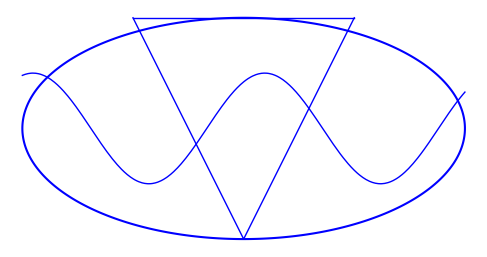

In [17]:
figura.show(figsize=5)

Área= 2.92296000000000
Tiempo= 12.901821613311768


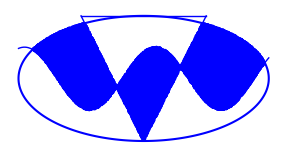

In [18]:
t0=walltime()
a,b,c,d=-2,2,-1,1
M=10^5
dentro=[]
for _ in xsrange(M):
    xx,yy=uniform(a,b),uniform(c,d)
    if (f(xx)-yy)*(g(xx)-yy)<0 and xx^2/4+yy^2<1:
        dentro.append((xx,yy))
print('Área=',(len(dentro)/M)*(b-a)*(d-c).n())
print('Tiempo=',walltime(t0))
figura+points(dentro,pointsize=5,figsize=3)